In [ ]:
# Bibliotecas que serão usadas no projeto
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import butter, resample_poly, savgol_filter, sosfilt, sosfilt_zi
from sklearn.linear_model import (
    Lasso,
    LassoCV,
    LinearRegression,
    MultiTaskLassoCV,
    Ridge,
    RidgeCV,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler  # type: ignore

# RNG padrão para reprodutibilidade
rng = np.random.default_rng(42)


---
### <a id='toc1_1_6_'></a>[Exemplos teóricos](#toc0_)

#### <a id='toc1_1_6_1_'></a>[Valor de casas em terrenos](#toc0_)


Comecemos agora a aplicar tudo que foi aprendido. Imagine a seguinte situação: **queremos prever o valor de um terreno baseado na área disponível**. Contudo, não temos apenas um dado de área, temos 4 valores que sofrem com erros de medida (vindos de equipamentos, aproximações, etc). Isso é um caso emblemático de um problema mal-condicionado.

Um adendo, usaremos as funções <span style="color:#97E1F1">RidgeCV</span>() e <span style="color:#97E1F1">LassoCV</span>(). A sigla CV significa **Cross Validation**, isso é um modelo que varia alguns hiperparâmetros das funções Lasso e Ridge para encontrar a força regularizadora ideal da regressão. No caso do Lasso e Ridge, esse hiperparâmetro é o alpha, que é o $\lambda$ da formula exposta na introdução. Manipula-lo irá alterar a força da regularização, $\lambda$'s muito baixo reduzem o modelo a um análogo da regularização linear convencional. Já $\lambda$'s muito altos destroem a informação do problema e gerar underfitting, que é quando um modelo não consegue se adaptar aos dados por alguma restrição <a id='toc0_'></a>[[1]](#toceq_1_).

In [ ]:
n=300 #exemplos

#areas disponíveis
area_real= rng.uniform(low=100,high=1000,size=n)

# lei do preço das casas
preco= 100000+2000*area_real+rng.normal(0,40000,size=n)

erro=0.002

#areas em cada unidade, inserimos um erro para simbolizar erros de conversão
area_m2=area_real*(1+rng.normal(0,erro,size=n))
area_cm2=area_real*10000*(1+rng.normal(0,erro,size=n))
area_pes2=area_real*10.7639*(1+rng.normal(0,erro,size=n))
area_palmo2=area_real*(1+rng.normal(0,erro,size=n))/(0.22**2)

X=np.column_stack([
    area_m2,
    area_cm2,
    area_pes2,
    area_palmo2
])
print("A matrix de áreas é:")
display(pd.DataFrame(X, columns=["Área em m²","Área em cm²","Área em pés²","Área em palmos²"]))
print(f"Seu rank é: {np.linalg.matrix_rank(X)}")
print(f"Seu número de condição é: {np.linalg.cond(X)}")

p_shape = X.shape[1]
matriz_correlacao = np.corrcoef(X, rowvar=False)
print("\nCorrelação:")
for i in range(p_shape):
    for j in range(i+1, p_shape):
            print(f"entre x{i+1} e x{j+1}: {matriz_correlacao[i,j]:.6f}")

A matrix de áreas é:


,Área em m²,Área em cm²,Área em pés²,Área em palmos²
0,632.006331,6.324051e+06,6778.125508,13038.470867
1,869.178634,8.645061e+06,9292.698800,17829.160761
2,104.222668,1.042248e+06,1120.522942,2152.968103
3,866.647337,8.654786e+06,9319.596593,17978.652678
4,657.769480,6.578684e+06,7075.453973,13556.772071
...,...,...,...,...
295,717.094191,7.156473e+06,7696.617114,14818.920791
296,120.900704,1.212176e+06,1305.527248,2498.760558
297,460.315756,4.588131e+06,4942.843136,9501.948586
298,889.522076,8.904447e+06,9534.056064,18377.129458


Seu rank é: 4
Seu número de condição é: 3956729.0846257573

Correlação:
entre x1 e x2: 0.999975
entre x1 e x3: 0.999974
entre x1 e x4: 0.999974
entre x2 e x3: 0.999978
entre x2 e x4: 0.999973
entre x3 e x4: 0.999976


Veja que a matrix é muito correlacionada, mas não perfeitamente. Isso permite com que o rank da matrix seja 4. Nota-se que o número de condição é extremamente alto, mas isso não se deve unicamente a correlação dos dados. Por mais alto que ela seja, existe uma diferença de escala muito grande entre alguns valores, isso acaba inflando muito esse número. Por isso, usa-se o StandardScaler para corrigir isso, para que haja uma comparação justa entre os termos.

Além disso, o StandardScaler impede que modelos como o Lasso escolham um dado simplesmente pelo tamanho dele, já que ele deixa todos os valores na mesma escala.

Antes de analisarmos os modelos, precisamos particionar os nossos dados em treino e teste.

In [ ]:
#Poderíamos aplicar StandardScaler no X antes de separa-lo, mas isso resultaria em dados de teste sendo escalados. Esse problema é nomeado como data leakage, que é como se já soubéssemos as respostas que queremos prever, dando uma falsa sensação de sucesso
X_train, X_test, y_train, y_test =train_test_split(
    X,
    preco,
    test_size=0.25,
    random_state=42
) 

# A função make_pipeline encadeia as transformações. O ridge é a regularização L2, o Lasso é a regularização L1 e o LinearRegression é o modelo sem regularização
ols_linear = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

ols_L2 = make_pipeline(
    StandardScaler(),
    RidgeCV()
)

ols_L1= make_pipeline(
    StandardScaler(),
    LassoCV()
)

In [ ]:
#Treinando modelo sem regressão
ols_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](4,)","[ 558.59,5584944.06, 6012.78, 11544.47]"


In [ ]:
#treinando modelo L2
ols_L2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('ridgecv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](4,)","[ 558.59,5584944.06, 6012.78, 11544.47]"


In [ ]:
#treinando modelo L1
ols_L1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](4,)","[ 558.59,5584944.06, 6012.78, 11544.47]"


Agora, está na hora de validar os três modelos para as casas.

OLS: w0= 202147.682, w1= 540652.533, w2= 382381.141, w3= -604537.716, 
Ridge: w0= 133792.662, w1= 157585.265, w2= 141322.263, w3= 87886.186, 
Lasso: w0= 520011.056, w1= 51.543, w2= 0.000, w3= 0.000, 


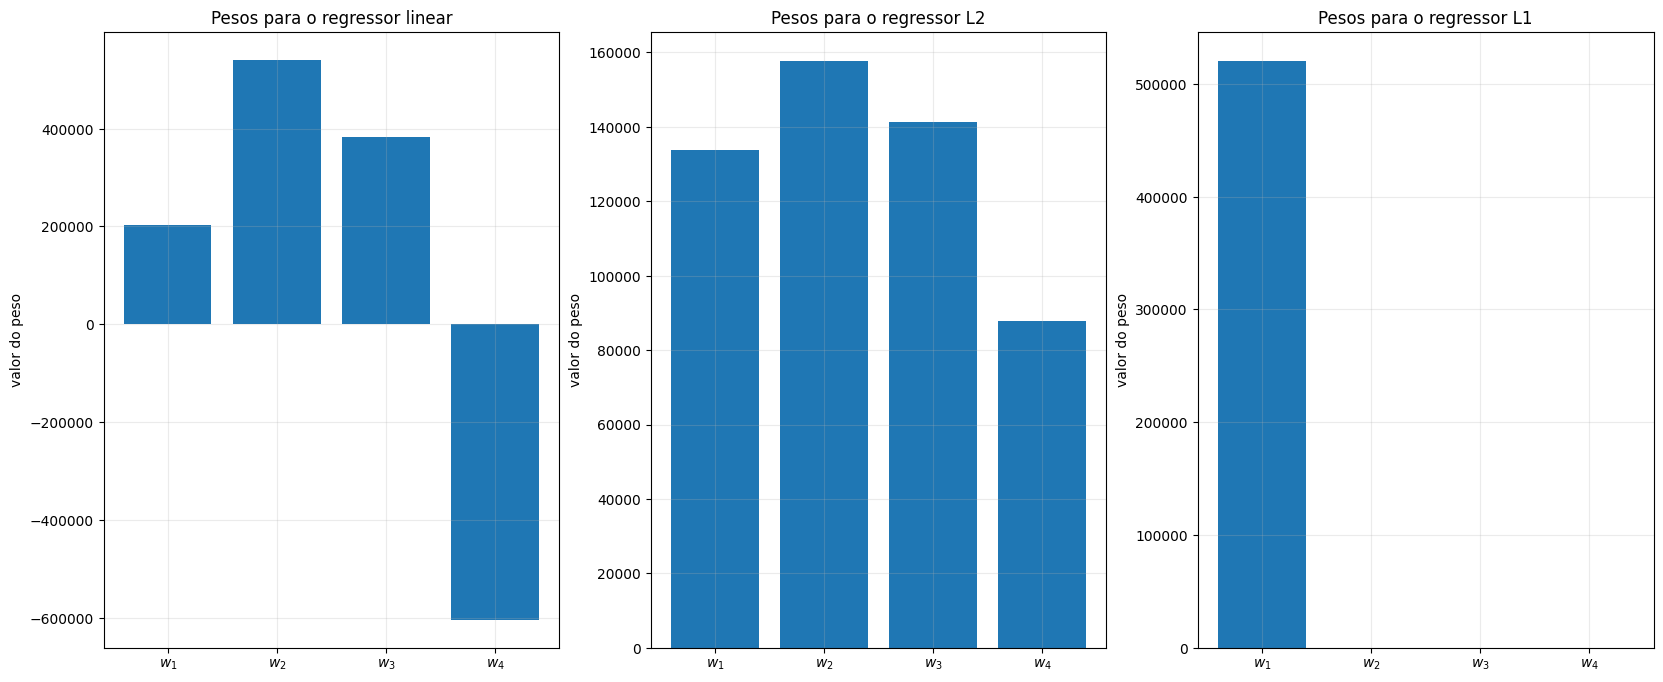

In [ ]:
y_linear_pred = ols_linear.predict(X_test)
y_L2_pred = ols_L2.predict(X_test)
y_L1_pred = ols_L1.predict(X_test)

#Recuperando os coeficientes
coef_linear=ols_linear[-1].coef_
coef_L2=ols_L2[-1].coef_
coef_L1=ols_L1[-1].coef_

print("OLS: ", end="")
for i, coef in enumerate(coef_linear):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

print("Ridge: ", end="")
for i, coef in enumerate(coef_L2):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

print("Lasso: ", end="")
for i, coef in enumerate(coef_L1):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].bar([r"$w_1$", r"$w_2$", r"$w_3$", r"$w_4$"], coef_linear)
axes[0].grid(alpha=0.25)

axes[0].set_ylabel("valor do peso")
axes[0].set_title("Pesos para o regressor linear")

#-----------------------------------------------------------------

axes[1].bar([r"$w_1$", r"$w_2$", r"$w_3$", r"$w_4$"], coef_L2)
axes[1].grid(alpha=0.25)

axes[1].set_ylabel("valor do peso")
axes[1].set_title("Pesos para o regressor L2")

#-----------------------------------------------------------------

axes[2].bar([r"$w_1$", r"$w_2$", r"$w_3$", r"$w_4$"], coef_L1)
axes[2].grid(alpha=0.25)

axes[2].set_ylabel("valor do peso")
axes[2].set_title("Pesos para o regressor L1")
plt.show()

Note como a discussão acima se concretizou, o OLS conseguiu achar uma resposta, mas os seus coeficientes são instáveis e pouco interpretáveis <a id='toc0_'></a>[[1]](#toceq_1_) <a id='toc0_'></a>[[3]](#toceq_3_), já que todos os dados são extremamente correlacionados. Já o Ridge buscou uma solução equilibrada que preservou coeficientes redundantes. Note que os coeficientes são estranhamente equilibrados para escalas tão diferentes de números, isso é devido ao StandardScaler que deixa todos os valores na mesma magnitude (padronização). Por fim, o Lasso buscou zerar coeficientes redundantes ou sem importância, concentrando a explicação dentro de poucas features.

In [ ]:
# Erro do modelo linear
MAE_linear = mean_absolute_error(y_test,y_linear_pred)
RMSE_linear = mean_squared_error(y_test,y_linear_pred)**(1/2)
R2_linear = r2_score(y_test, y_linear_pred)

#Erro do modelo L2
MAE_L2 = mean_absolute_error(y_test,y_L2_pred)
RMSE_L2 = mean_squared_error(y_test,y_L2_pred)**(1/2)
R2_L2 = r2_score(y_test, y_L2_pred)

#Erro do modelo L1  
MAE_L1 = mean_absolute_error(y_test,y_L1_pred)
RMSE_L1 = mean_squared_error(y_test,y_L1_pred)**(1/2)
R2_L1 = r2_score(y_test, y_L1_pred)

print(f"Erro absoluto médio do modelo OLS: {MAE_linear:.2f}")
print(f"Erro quadrático médio regular do modelo OLS: {RMSE_linear:.2f}")
print(f"R² do OLS: {R2_linear:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Ridge: {MAE_L2:.2f}")
print(f"Erro quadrático médio regular do modelo Ridge: {RMSE_L2:.2f}")
print(f"R² do Ridge: {R2_L2:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Lasso: {MAE_L1:.2f}")
print(f"Erro quadrático médio regular do modelo Lasso: {RMSE_L1:.2f}")
print(f"R² do Lasso: {R2_L1:.5f}")

Erro absoluto médio do modelo OLS: 34839.45
Erro quadrático médio regular do modelo OLS: 43078.12
R² do OLS: 0.99335
------------------------------------------------------------------
Erro absoluto médio do modelo Ridge: 33767.17
Erro quadrático médio regular do modelo Ridge: 42316.79
R² do Ridge: 0.99358
------------------------------------------------------------------
Erro absoluto médio do modelo Lasso: 33563.21
Erro quadrático médio regular do modelo Lasso: 42136.35
R² do Lasso: 0.99364


A princípio, esse resultado pode se mostrar decepcionante para toda a discussão que tivemos acima, mesmo que o erro do OLS seja levemente pior, ainda não é suficiente para descartar o modelo como um bom candidato para uma previsão (até porque ele é mais barato do que o Lasso). Contudo, os testes realizados avaliam somente interpolação, como os modelos saem para casos de extrapolação?


In [ ]:
n=300 #exemplos

#areas disponíveis
area_real= rng.uniform(low=1000,high=10000,size=n)

# lei do preço das casas
preco= 100000+2000*area_real+rng.normal(0,40000,size=n)

erro=0.002

#areas em cada unidade, inserimos um erro para simbolizar erros de conversão
area_m2=area_real*(1+rng.normal(0,erro,size=n))
area_cm2=area_real*10000*(1+rng.normal(0,erro,size=n))
area_pes2=area_real*10.7639*(1+rng.normal(0,erro,size=n))
area_palmo2=area_real*(1+rng.normal(0,erro,size=n))/(0.22**2)

X=np.column_stack([
    area_m2,
    area_cm2,
    area_pes2,
    area_palmo2
])

y_linear_pred = ols_linear.predict(X)
y_L2_pred = ols_L2.predict(X)
y_L1_pred = ols_L1.predict(X)

MAE_linear = mean_absolute_error(preco,y_linear_pred)
RMSE_linear = mean_squared_error(preco,y_linear_pred)**(1/2)
R2_linear = r2_score(preco, y_linear_pred)

#Erro do modelo L2
MAE_L2 = mean_absolute_error(preco,y_L2_pred)
RMSE_L2 = mean_squared_error(preco,y_L2_pred)**(1/2)
R2_L2 = r2_score(preco, y_L2_pred)

#Erro do modelo L1  
MAE_L1 = mean_absolute_error(preco,y_L1_pred)
RMSE_L1 = mean_squared_error(preco,y_L1_pred)**(1/2)
R2_L1 = r2_score(preco, y_L1_pred)

print(f"Erro absoluto médio do modelo OLS: {MAE_linear:.2f}")
print(f"Erro quadrático médio regular do modelo OLS: {RMSE_linear:.2f}")
print(f"R² do OLS: {R2_linear:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Ridge: {MAE_L2:.2f}")
print(f"Erro quadrático médio regular do modelo Ridge: {RMSE_L2:.2f}")
print(f"R² do Ridge: {R2_L2:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Lasso: {MAE_L1:.2f}")
print(f"Erro quadrático médio regular do modelo Lasso: {RMSE_L1:.2f}")
print(f"R² do Lasso: {R2_L1:.5f}")

Erro absoluto médio do modelo OLS: 49811.94
Erro quadrático médio regular do modelo OLS: 62920.91
R² do OLS: 0.99985
------------------------------------------------------------------
Erro absoluto médio do modelo Ridge: 40540.95
Erro quadrático médio regular do modelo Ridge: 51156.95
R² do Ridge: 0.99990
------------------------------------------------------------------
Erro absoluto médio do modelo Lasso: 49014.12
Erro quadrático médio regular do modelo Lasso: 60300.47
R² do Lasso: 0.99986


Além da seed 42, foram testadas algumas outras para avaliar a consistência, como a 43, a 44 e a 1029, desta afirmação: para extrapolação, o erro quadrático médio e o erro absoluto médio é maior no OLS e no L1 do que no L2. Foi visualizado que essa diferença ficou de até 20.000, mas não é possível afirmar que isso é consistente. Isso não conclui que um é necessariamente melhor que o outro, apenas que, na média, L2 gera coeficientes que extrapolam melhor seguindo a mesma lei linear, para o positivo, que o OLS e o L1. Isso não significa que o OLS e o L1 são modelos ruins, basta analisar o $R^2$, o contexto da ordem de grandeza e o espaço que eles começam a falhar que podemos inferir que o modelo, na realidade, pode ser até mais vantajoso nesse caso do que o L2.

Devemos lembrar também que essa extrapolação assume que a lei do valor de terrenos continua igual para terrenos maiores, caso ela mude, talvez os três modelos falhem miseravelmente. Mas, existe algum preferível nesse intervalo? Sim, como discutimos anteriormente, sabendo as hipóteses do L1 e L2, podemos interpretar os seus coeficientes, dificilmente poderíamos fazer isso com o OLS nesse caso. Entretanto, e se isso não fosse o que desejamos?

Para argumentar em defesa do OLS, pense no seguinte: a maioria dos terrenos no Brasil orbitam em volta de $680  \ m^2$ <a id='toc0_'></a>[{3}](#tocap_3_). Logo, para um modelo de previsão de terrenos populares, ele realiza o seu trabalho de forma excepcional na média. Ademais, realizar uma regressão linear normal é computacionalmente mais barato do que L1 (O L2 tem solução fechada, então, normalmente, tem um custo parecido), logo, será que realmente vale a pena escolher um modelo em que a precisão do $R^2$ muda na terceira casa depois da vírgula? Por fim, o erro aparece de forma mais gritante porque a escala dos números é muito maior, logo, mesmo que ele erre pouco, esse número é grande e cresce quadraticamente.

Entretanto, também há bons argumentos contra ele. Querendo ou não, nessa seed escolhida, o erro do L2 é menor que o do OLS e do L1. Para terrenos gigantes, como para latifúndios ou grandes mansões, isso significa que, em média, os compradores que usam o OLS e o L1 podem pagar mais ou menos em um terreno. Nesse cenário, nota-se uma certa vantagem em usa-lo como bom candidato substituto do OLS comum e do L1.

Veja que o teste de extrapolação para baixo não foi realizado, isso é proposital, já que extrapolar para baixo faz com que o ruído introduzido fique na ordem de grandeza do valor calculado, tornando quase qualquer preço não confiável. Tal caso simplesmente não contribui para a discussão, já que seria uma previsão do gerador de números aleatórios do numpy mais do que sobre o problema em si.

Por fim, os coeficientes. Independente do quão acurado cada um seja, o OLS gera pesos que, mesmo que cheguem na resposta, não tem significado plausível. Como que aumentar a área em $m^2$ aumenta o preço, mas aumentar em $palmos^2$ não? O OLS gera uma resposta, mas ela não é fisicamente confiável ou interpretável, é apenas um padrão que o modelo encontrou. Já o L2 e o L1 tem interpretações bem plausíveis pois sabemos o que eles estão supondo, sendo melhores para interpretar tendencias de algo. Então, talvez não estejamos buscando um modelo mais preciso ou mais leve, talvez queremos analisar como uma tendencia se comporta. Assim, com as hipóteses corretas, L2 e L1 adquirem novas praticidades perante as abordagens normais.

Antes de partirmos para a próxima seção, queria tirar um momento para discutir algo interessante. Veja o $R^2$ do Ridge e, depois, o MAE/RMSE dele, notou algo? Como pode um $R^2$ tão próximo de $1$ com um erro tão grande? Quanto mais subimos a escala, maior é a variância do $y$, isso faz com que erros que pareçam grandes sejam minúsculos perante a esse valor, diminuindo o $q^2$ discutido em [Regressão Linear simples](#toc1_1_2_). 

Isso é uma lição importante: não interprete nenhuma métrica de forma isolada, todas elas são relativas ao contexto do seu problema. Poderíamos supor que um MAE/RMSE dessa magnitude comprovavam que o problema é incapaz de prever qualquer coisa, enquanto o modelo da sessão final, spoiler de [Modelos preditivos](#toc1_1_7_4_), é fantástico por ter um erro de apenas 18. Esse não é o caso, o modelo de previsão de casas, supondo que ela siga a regra proposta, é fenomenal, enquanto o outro... veremos mais tarde.

Por isso, coisas que pareçam conflitantes, na realidade, podem coexistir a depender do contexto do problema. Sempre se atente a isso para não tirar conclusões estatísticas precipitadas. 

#### <a id='toc1_1_6_2_'></a>[Sistema Linear possível e indeterminado](#toc0_)



Agora, quero que o leitor imagine o seguinte cenário: você recebeu uma medida que apresenta 200 parâmetros, mas somente 100 medidas. Isso é um caso absurdo de sistema sub-determinado, metade dos parâmetros são direções independentes no espaço dos coeficientes que não são determinados pelos exemplos. Em um mundo onde só podemos usar OLS, isso seria um caso que voltaria direto para o laboratório, não porque o OLS não pode achar uma solução (ele acha), mas ela não é única e nem confiável. Porém, como será que as novas técnicas reagem a isso?


In [ ]:
n = 100   # número de exemplos
p = 200  # número de atributos

X = rng.normal(0, 1, size=(n, p))

# Pesos usados para gerar os dados
w_true = np.zeros(p, dtype=float)
# w_true = rng.normal(0, 1, size=p)
numeros = rng.choice(range(p), size=10, replace=False)

w_true=list(w_true)

#Para garantir que não haverá 0, vou espelhar o intervalo
for i in numeros:
    w_true[i]=rng.choice(range(1, 100))*rng.choice([-1,1])

w_true=np.array(w_true)

# Sem ruído para evidenciar a não unicidade da solução
y = X @ w_true

Aqui pegamos um caso extremo, escolhemos 10 parâmetros para realmente impactarem na resposta. A princípio, isso é para demonstrar o potencial do L1 em uma resposta esparsa, mas mostraremos o caso em que isso é falso mais para frente.

In [ ]:
#Poderíamos aplicar StandardScaler no X antes de separa-lo, mas isso resultaria em dados de teste sendo escalados. Esse problema é nomeado como data leakage, que é como se já soubéssemos as respostas que queremos prever, dando uma falsa sensação de sucesso
X_train, X_test, y_train, y_test =train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
) 

# A função make_pipeline encadeia as transformações. O ridge é a regularização L2, o Lasso é a regularização L1 e o LinearRegression é o modelo sem regularização
ols_linear = make_pipeline(
    LinearRegression()
)

ols_L2 = make_pipeline(
    RidgeCV()
)

ols_L1= make_pipeline(
    LassoCV()
)

Veja que aqui o StandardScaler foi retirado, porque? Simples, não há necessidade de padronizar os dados. Todos estão na mesma proporção e foram feitos propositalmente assim, logo, para mater os coeficientes estimados diretamente comparáveis não vamos aplicar o StandardScaler.

In [ ]:
#Treinando modelo sem regressão
ols_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#treinando modelo L2
ols_L2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ridgecv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for 

In [ ]:
#treinando modelo L1
ols_L1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000


OLS: w0= 3.449, w1= -5.899, w2= 3.048, w3= -6.059, w4= 7.766, w5= 0.564, w6= 2.509, w7= 1.903, w8= 4.341, w9= -9.209, w10= -0.661, w11= 1.400, w12= 2.779, w13= 2.170, w14= -2.650, w15= -2.240, w16= 12.693, w17= -1.579, w18= -7.190, w19= 4.356, w20= 3.824, w21= -1.364, w22= -10.344, w23= -6.999, w24= 0.982, w25= 4.444, w26= -3.962, w27= 11.183, w28= 8.976, w29= -5.631, w30= 6.686, w31= -2.013, w32= 3.403, w33= 3.142, w34= 1.585, w35= -7.022, w36= -6.961, w37= 4.533, w38= 8.327, w39= -6.923, w40= -6.352, w41= 3.510, w42= -4.933, w43= -3.156, w44= 1.500, w45= -4.241, w46= -2.843, w47= -6.172, w48= 2.422, w49= -1.054, w50= -4.960, w51= -6.950, w52= -1.104, w53= -8.544, w54= 2.737, w55= -0.514, w56= -0.665, w57= -6.100, w58= -10.503, w59= -19.738, w60= 6.606, w61= 0.569, w62= 3.213, w63= 2.060, w64= -1.766, w65= -2.629, w66= 4.007, w67= 0.222, w68= 4.199, w69= -5.507, w70= 5.794, w71= -10.393, w72= 1.708, w73= 1.271, w74= 1.844, w75= -2.330, w76= -4.113, w77= -0.066, w78= -8.424, w79= 4.255

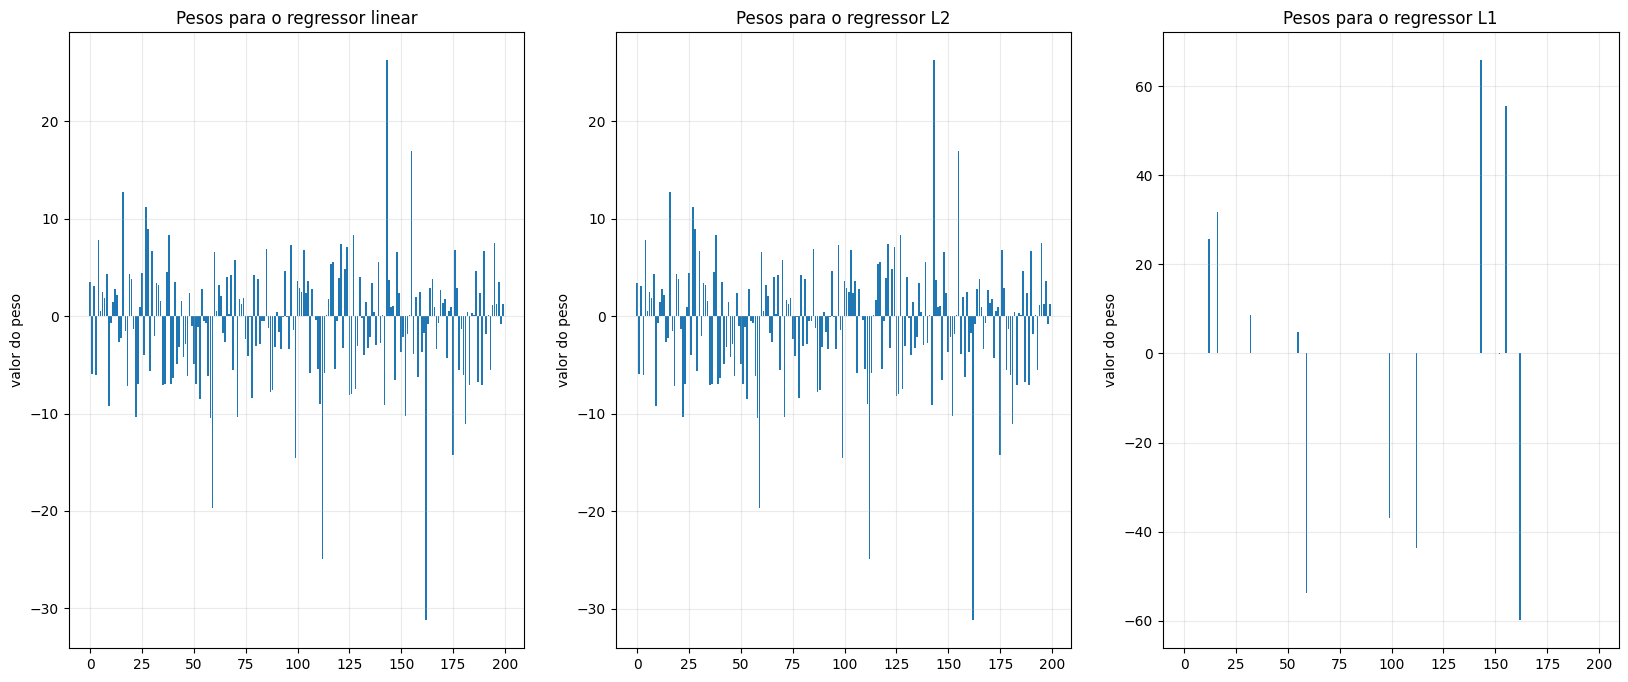

In [ ]:
y_linear_pred = ols_linear.predict(X_test)
y_L2_pred = ols_L2.predict(X_test)
y_L1_pred = ols_L1.predict(X_test)

#Recuperando os coeficientes
coef_linear=ols_linear[-1].coef_
coef_L2=ols_L2[-1].coef_
coef_L1=ols_L1[-1].coef_

print("OLS: ", end="")
for i, coef in enumerate(coef_linear):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

print("Ridge: ", end="")
for i, coef in enumerate(coef_L2):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

print("Lasso: ", end="")
for i, coef in enumerate(coef_L1):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()


# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].bar(np.arange(p), coef_linear)
axes[0].grid(alpha=0.25)

axes[0].set_ylabel("valor do peso")
axes[0].set_title("Pesos para o regressor linear")

#-----------------------------------------------------------------

axes[1].bar(np.arange(p), coef_L2)
axes[1].grid(alpha=0.25)

axes[1].set_ylabel("valor do peso")
axes[1].set_title("Pesos para o regressor L2")

#-----------------------------------------------------------------

axes[2].bar(np.arange(p), coef_L1)
axes[2].grid(alpha=0.25)

axes[2].set_ylabel("valor do peso")
axes[2].set_title("Pesos para o regressor L1")
plt.show()

Aqui, algo extremamente interessante aparece ao leitor atento: veja o gráfico do L2 e do regressor linear padrão, você vê uma diferença grotesca entre eles? Como há poucos exemplo, nenhum dos dois consegue recuperar bem o verdadeiro vetor solução, mas porque será que ficaram tão parecidos? 

Veja a célula abaixo, vamos imprimir o alpha (simbolizado como $\lambda$ acima).

In [ ]:
print(f"Lambda do Ridge: {ols_L2[-1].alpha_}")

Lambda do Ridge: 0.1


Esse valor é pequeno, isso significa que a regularização L2 não está impactando muito na resposta. Obviamente, há um impacto, se olharmos atentamente ao gráfico, existem colunas que mudam entre o linear e o ridge. Contudo, a força é pequena o suficiente para gerar uma forma parecida entre os dois.

Ademais, vale notar outra coisa também, o intervalo de busca do <span style="color:#97E1F1">RidgeCV</span>() tem como mínimo o valor de $\lambda$ de $0.1$. Logo, talvez ele buscasse um valor ainda menor que o tornaria ainda mais similar com o OLS.

In [ ]:
# Erro do modelo linear
MAE_linear = mean_absolute_error(y_test,y_linear_pred)
RMSE_linear = mean_squared_error(y_test,y_linear_pred)**(1/2)
R2_linear = r2_score(y_test, y_linear_pred)

#Erro do modelo L2
MAE_L2 = mean_absolute_error(y_test,y_L2_pred)
RMSE_L2 = mean_squared_error(y_test,y_L2_pred)**(1/2)
R2_L2 = r2_score(y_test, y_L2_pred)

#Erro do modelo L1  
MAE_L1 = mean_absolute_error(y_test,y_L1_pred)
RMSE_L1 = mean_squared_error(y_test,y_L1_pred)**(1/2)
R2_L1 = r2_score(y_test, y_L1_pred)

print(f"Erro absoluto médio do modelo OLS: {MAE_linear:.2f}")
print(f"Erro quadrático médio regular do modelo OLS: {RMSE_linear:.2f}")
print(f"R² do OLS: {R2_linear:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Ridge: {MAE_L2:.2f}")
print(f"Erro quadrático médio regular do modelo Ridge: {RMSE_L2:.2f}")
print(f"R² do Ridge: {R2_L2:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Lasso: {MAE_L1:.2f}")
print(f"Erro quadrático médio regular do modelo Lasso: {RMSE_L1:.2f}")
print(f"R² do Lasso: {R2_L1:.5f}")

Erro absoluto médio do modelo OLS: 75.37
Erro quadrático médio regular do modelo OLS: 93.70
R² do OLS: 0.53122
------------------------------------------------------------------
Erro absoluto médio do modelo Ridge: 75.40
Erro quadrático médio regular do modelo Ridge: 93.72
R² do Ridge: 0.53099
------------------------------------------------------------------
Erro absoluto médio do modelo Lasso: 0.63
Erro quadrático médio regular do modelo Lasso: 0.74
R² do Lasso: 0.99997


Aqui temos um resultado muito explicito, o modelo de L1, para essa seed, performou muito melhor que os outros dois, obtendo uma reta que representa quase que integralmente os valores de test. Contudo, isso não é apenas o que desejamos, dado que esse é um toy model e temos os pesos verdadeiros, queremos, no final, um modelo que preveja corretamente os pesos de cada parâmetro. Analisaremos isso a seguir.

In [ ]:
#Erro de cada um dos coeficientes
erro_coef_linear = (np.linalg.norm(coef_linear-w_true)/np.linalg.norm(w_true))
erro_coef_L2 = (np.linalg.norm(coef_L2-w_true)/np.linalg.norm(w_true))
erro_coef_L1 = (np.linalg.norm(coef_L1-w_true)/np.linalg.norm(w_true)) 

#Depois da regressão, quanto pesos sobreviveram?
lim = 1e-6
num_coef_linear= np.sum(np.abs(coef_linear)>lim)
num_coef_L2= np.sum(np.abs(coef_L2)>lim)
num_coef_L1= np.sum(np.abs(coef_L1)>lim)

print(f"Erro dos coeficientes do OLS: {erro_coef_linear}")
print(f"Erro dos coeficientes do Ridge: {erro_coef_L2}")
print(f"Erro dos coeficientes do Lasso: {erro_coef_L1}")
print("------------------------------------------------------------------")
print(f"Quantos coeficientes sobrevivem no OLS: {num_coef_linear}")
print(f"Quantos coeficientes sobrevivem no Ridge: {num_coef_L2}")
print(f"Quantos coeficientes sobrevivem no Lasso: {num_coef_L1}")


Erro dos coeficientes do OLS: 0.7706225150764291
Erro dos coeficientes do Ridge: 0.7706227253183361
Erro dos coeficientes do Lasso: 0.0057184585577489755
------------------------------------------------------------------
Quantos coeficientes sobrevivem no OLS: 200
Quantos coeficientes sobrevivem no Ridge: 200
Quantos coeficientes sobrevivem no Lasso: 12


O erro de coeficientes do Lasso é quase 135 vezes menor que os outros usando a seed 42. Esse número varia usando seeds adicionais, mas uma coisa é consistente: o Lasso tem um erro absurdamente menor que os outros e acha um número de coeficientes próximos do real. Juntando isso com o $R^2$ de basicamente 1, a regularização L1 é a única que consegue recuperar bem um vetor resposta por causa da hipótese do modelo <a id='toc0_'></a>[[3]](#toceq_3_) <a id='toc0_'></a>[[5]](#toceq_5_). 

Ademais, mesmo sendo somente 10 coeficientes reais, o Lasso encontrou 12 coeficientes. Mesmo que ele resolva bem, essa resolução é uma aproximação. Não podemos esperar que esse modelo consiga cravar a resposta de forma perfeita.

Tal conclusão se alinha exatamente com o previsto, mas isso ocorreu pois a solução é esparsa, como o L1 se comporta para o caso contrário?

In [ ]:
n = 100   # número de exemplos
p = 200  # número de atributos

X = rng.normal(0, 1, size=(n, p))

# Pesos usados para gerar os dados
w_true = np.zeros(p, dtype=float)
# w_true = rng.normal(0, 1, size=p)
numeros = rng.choice(range(p), size=p, replace=False)

w_true=list(w_true)

for i in numeros:
    w_true[i]=rng.choice(range(-100, 100))

w_true=np.array(w_true)

# Sem ruído para evidenciar a não unicidade da solução
y = X @ w_true

X_train, X_test, y_train, y_test =train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
) 

Apenas um adendo, mesmo que eu diga que todas as 200 features importam, ainda é possível um coeficiente cair no 0. Então leve essa afirmação com uma pitada de sal.

In [ ]:
#Treinando modelo sem regressão
ols_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#treinando modelo L2
ols_L2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ridgecv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for 

In [ ]:
#treinando modelo L1
ols_L1.fit(X_train, y_train)

C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.771026e+04, tolerance: 4.220e+03
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000


Como o Lasso não é um modelo de solução analítica fixa e nesse caso o Ridge e o OLS são, ele tem problemas de convergência quando tenta usar Coordinate Descent. Isso é um problema que ocorre quando o modelo atinge o nível máximo de iterações permitidas mas não acerta abaixo da tolerância mínima.

Isso é uma consequência exatamente do que discutiremos, quando a hipótese do Lasso é falsa, ele tem dificuldades de derivar uma resposta.

OLS: w0= -85.789, w1= -18.402, w2= -21.032, w3= -8.209, w4= 55.494, w5= 19.397, w6= -20.903, w7= 33.811, w8= -58.214, w9= -4.359, w10= -6.773, w11= 4.365, w12= -40.052, w13= 7.128, w14= 9.866, w15= 41.244, w16= -0.895, w17= -30.083, w18= -32.721, w19= 35.998, w20= 36.478, w21= -23.783, w22= 4.491, w23= 27.426, w24= -6.961, w25= -15.446, w26= -1.789, w27= -21.114, w28= 38.071, w29= -17.882, w30= 34.532, w31= -0.355, w32= -33.262, w33= 4.484, w34= -1.878, w35= -42.212, w36= 8.983, w37= -28.593, w38= 1.147, w39= 14.473, w40= -18.932, w41= -17.612, w42= -23.275, w43= 19.739, w44= -19.588, w45= 56.932, w46= -54.575, w47= 11.500, w48= 16.147, w49= -18.687, w50= 29.682, w51= 33.824, w52= 50.959, w53= -15.886, w54= 8.882, w55= 9.788, w56= 62.233, w57= 19.032, w58= 18.929, w59= 64.409, w60= -25.097, w61= 18.234, w62= 21.502, w63= -2.073, w64= -40.572, w65= -36.195, w66= 64.710, w67= 29.810, w68= 3.686, w69= 30.909, w70= 48.686, w71= 40.960, w72= 5.089, w73= -42.135, w74= 0.635, w75= 27.824, w76

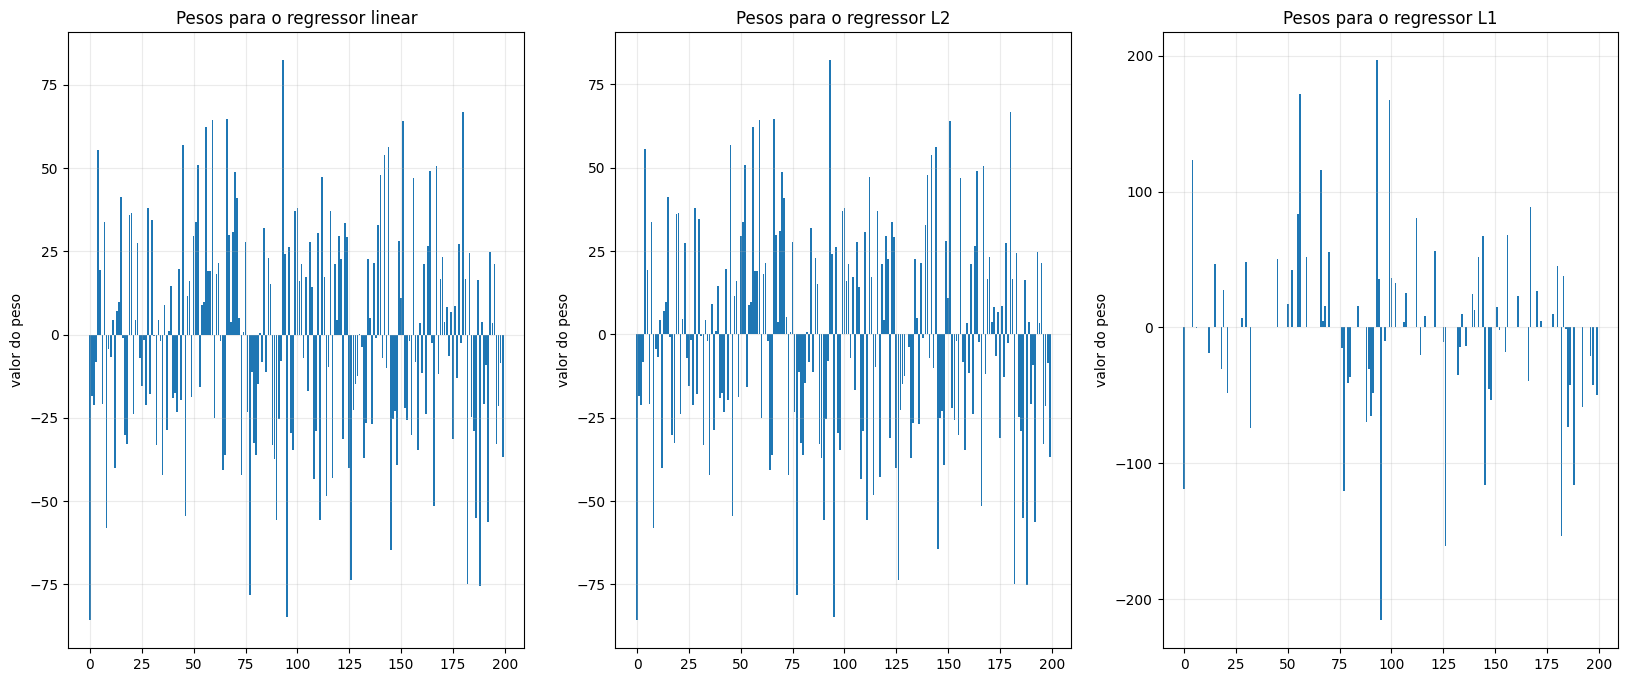

In [ ]:
y_linear_pred = ols_linear.predict(X_test)
y_L2_pred = ols_L2.predict(X_test)
y_L1_pred = ols_L1.predict(X_test)

#Recuperando os coeficientes
coef_linear=ols_linear[-1].coef_
coef_L2=ols_L2[-1].coef_
coef_L1=ols_L1[-1].coef_

print("OLS: ", end="")
for i, coef in enumerate(coef_linear):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

print("Ridge: ", end="")
for i, coef in enumerate(coef_L2):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()

print("Lasso: ", end="")
for i, coef in enumerate(coef_L1):
    print(rf"w{i}= {coef:.3f}, ", end="")
print()


# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].bar(np.arange(p), coef_linear)
axes[0].grid(alpha=0.25)

axes[0].set_ylabel("valor do peso")
axes[0].set_title("Pesos para o regressor linear")

#-----------------------------------------------------------------

axes[1].bar(np.arange(p), coef_L2)
axes[1].grid(alpha=0.25)

axes[1].set_ylabel("valor do peso")
axes[1].set_title("Pesos para o regressor L2")

#-----------------------------------------------------------------

axes[2].bar(np.arange(p), coef_L1)
axes[2].grid(alpha=0.25)

axes[2].set_ylabel("valor do peso")
axes[2].set_title("Pesos para o regressor L1")
plt.show()

In [ ]:
# Erro do modelo linear
MAE_linear = mean_absolute_error(y_test,y_linear_pred)
erro_coef_linear = (np.linalg.norm(coef_linear-w_true)/np.linalg.norm(w_true))
num_coef_linear= np.sum(np.abs(coef_linear)>lim)
RMSE_linear = mean_squared_error(y_test,y_linear_pred)**(1/2)
R2_linear = r2_score(y_test, y_linear_pred)

#Erro do modelo L2
MAE_L2 = mean_absolute_error(y_test,y_L2_pred)
erro_coef_L2 = (np.linalg.norm(coef_L2-w_true)/np.linalg.norm(w_true))
num_coef_L2= np.sum(np.abs(coef_L2)>lim)
RMSE_L2 = mean_squared_error(y_test,y_L2_pred)**(1/2)
R2_L2 = r2_score(y_test, y_L2_pred)

#Erro do modelo L1  
MAE_L1 = mean_absolute_error(y_test,y_L1_pred)
erro_coef_L1 = (np.linalg.norm(coef_L1-w_true)/np.linalg.norm(w_true)) 
num_coef_L1= np.sum(np.abs(coef_L1)>lim)
RMSE_L1 = mean_squared_error(y_test,y_L1_pred)**(1/2)
R2_L1 = r2_score(y_test, y_L1_pred)

print(f"Erro absoluto médio do modelo OLS: {MAE_linear:.2f}")
print(f"Erro dos coeficientes do OLS: {erro_coef_linear}")
print(f"Quantos coeficientes sobrevivem no OLS: {num_coef_linear}")
print(f"Erro quadrático médio regular do modelo OLS: {RMSE_linear:.2f}")
print(f"R² do OLS: {R2_linear:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Ridge: {MAE_L2:.2f}")
print(f"Erro dos coeficientes do Ridge: {erro_coef_L2}")
print(f"Quantos coeficientes sobrevivem no Ridge: {num_coef_L2}")
print(f"Erro quadrático médio regular do modelo Ridge: {RMSE_L2:.2f}")
print(f"R² do Ridge: {R2_L2:.5f}")
print("------------------------------------------------------------------")
print(f"Erro absoluto médio do modelo Lasso: {MAE_L1:.2f}")
print(f"Erro dos coeficientes do Lasso: {erro_coef_L1}")
print(f"Quantos coeficientes sobrevivem no Lasso: {num_coef_L1}")
print(f"Erro quadrático médio regular do modelo Lasso: {RMSE_L1:.2f}")
print(f"R² do Lasso: {R2_L1:.5f}")

Erro absoluto médio do modelo OLS: 545.57
Erro dos coeficientes do OLS: 0.8113875444031765
Quantos coeficientes sobrevivem no OLS: 200
Erro quadrático médio regular do modelo OLS: 681.77
R² do OLS: 0.22979
------------------------------------------------------------------
Erro absoluto médio do modelo Ridge: 545.61
Erro dos coeficientes do Ridge: 0.8113876838032402
Quantos coeficientes sobrevivem no Ridge: 200
Erro quadrático médio regular do modelo Ridge: 681.78
R² do Ridge: 0.22977
------------------------------------------------------------------
Erro absoluto médio do modelo Lasso: 630.60
Erro dos coeficientes do Lasso: 1.0305739690745788
Quantos coeficientes sobrevivem no Lasso: 77
Erro quadrático médio regular do modelo Lasso: 761.88
R² do Lasso: 0.03815


Note que nesse caso, a precisão do L1 consegue ser pior que o próprio OLS. Isso é importantíssimo de se ressaltar, o modelo L1 tem consigo uma hipótese clara de esparsidade da resposta, aplicá-lo em um problema que não segue essa estrutura irá resultar em um algoritmo ruim de previsão. 

Curiosamente, o $R^2$ parece ter diminuído enormemente para os outros modelo, eles não deveriam permanecer inalterados? Quando há um número de exemplos menor que o de parâmetros, o Ridge e o LinearRegression tentam resolver o problema dentro de um subespaço do problema, este tem dimensão igual ao número de exemplos. A questão toda é, se a dimensionalidade efetiva do espaço se encaixar dentro do subespaço definido, então o hiperplano de dimensão $n$ é capaz de capturar parte dessa resposta. Então, mesmo uma solução de norma mínima, que é usado em casos sub-determinados pelo LinearRegression e pelo Ridge (que, pelo CV, usa um alpha muito pequeno), é capaz de contemplar a solução.

Contudo, para um número de parâmetros reais maior, esse espaço tem muito mais graus de liberdade. Logo, esse subespaço deixa parte da solução em um espaço nulo que é inacessível sem hipóteses adicionais, como foi o caso de assumir que a solução é esparsa.